<a href="https://colab.research.google.com/github/elisamezzi/Progetto_IDSAPCProg_gruppo5/blob/Isabella%2Ffase3/notebooks/IntroDSePCProg_gruppo5_Attritition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Progetto Data Science e Pensiero Computazionale <br>
# A.A. 2025/2026<br>


## Membri del gruppo numero 5

Il gruppo numero **5** è composto da:


*   **Isabella Manetti**: matr.0001216209, isabella.manetti2@studio.unibo.it
*   **Elisa Mezzi**: matr.0001231137, elisa.mezzi@studio.unibo.it
* **Maddalena Vannini**: matr.0001180470,




## Fase 1 - descrizione del dataset

Requisiti - almeno:

*   8 domande/ipotesi
*   5 statistiche descrittive;
*   3 riflessioni critiche sui dati.

Esempi:


*   class imbalance;
*   outlier;
*   feature correlate;
*   dati mancanti;
*   feature sospette.

## Preparazione dell'ambiente

In [15]:
import pandas as pd

url = "https://raw.githubusercontent.com/elisamezzi/Progetto_IDSAPCProg_gruppo5/main/data/Employee_Attrition.csv"
df_EA = pd.read_csv(url)

#Chiesto a LLM come bypassare il problema del recupero del dataset colab - github, letto via URL raw

##Analisi descrittiva del dataset

In [ ]:
num_righe = df_EA.shape[0]
num_colonne = df_EA.shape[1]
print("EMPLOYEE ATTRITITION DATASET")
print("Numero righe", num_righe)
print("Numero colonne", num_colonne)
print(" ")

EMPLOYEE ATTRITITION DATASET
Numero righe 1470
Numero colonne 35
 


In [ ]:
#verifico presenza valori nulli nel dataset.
print(df_EA.isnull().sum()[df_EA.isnull().sum() > 0])

#-> dataset pulito

Series([], dtype: int64)


Come sono divise le variabili?

In [ ]:
df_EA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

Divido la tipologia di colonne (numeriche, categoriche pure, categoriche codificate)

In [ ]:
numeriche = df_EA.select_dtypes(include=['int64', 'float64']).columns.tolist() #trova tutte le colonne che hanno dtype int64 o float64 nel dataframe, e le salva in una lista chiamata numeriche.

#divido in sottoinsiemi le categoriche in codificate e pure (in base a file description)
cat_pure = ['Attrition', 'Gender', 'Department', 'JobRole',
                'MaritalStatus', 'BusinessTravel', 'EducationField',
                'OverTime', 'Over18']

cat_codificate = ['Education', 'EnvironmentSatisfaction', 'JobInvolvement',
                'JobSatisfaction', 'PerformanceRating',
                'RelationshipSatisfaction', 'WorkLifeBalance']

numeriche_pure = [col for col in numeriche if col not in cat_codificate]
#verifico visivamente che le tre liste siano corrette
display(df_EA[numeriche_pure].head())
print()
display(df_EA[cat_pure].head())
print()
display(df_EA[cat_codificate].head())


,Age,DailyRate,DistanceFromHome,EmployeeCount,EmployeeNumber,HourlyRate,JobLevel,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1102,1,1,1,94,2,5993,19479,8,11,80,0,8,0,6,4,0,5
1,49,279,8,1,2,61,2,5130,24907,1,23,80,1,10,3,10,7,1,7
2,37,1373,2,1,4,92,1,2090,2396,6,15,80,0,7,3,0,0,0,0
3,33,1392,3,1,5,56,1,2909,23159,1,11,80,0,8,3,8,7,3,0
4,27,591,2,1,7,40,1,3468,16632,9,12,80,1,6,3,2,2,2,2


,Attrition,Gender,Department,JobRole,MaritalStatus,BusinessTravel,EducationField,OverTime,Over18
0,Yes,Female,Sales,Sales Executive,Single,Travel_Rarely,Life Sciences,Yes,Y
1,No,Male,Research & Development,Research Scientist,Married,Travel_Frequently,Life Sciences,No,Y
2,Yes,Male,Research & Development,Laboratory Technician,Single,Travel_Rarely,Other,Yes,Y
3,No,Female,Research & Development,Research Scientist,Married,Travel_Frequently,Life Sciences,Yes,Y
4,No,Male,Research & Development,Laboratory Technician,Married,Travel_Rarely,Medical,No,Y


,Education,EnvironmentSatisfaction,JobInvolvement,JobSatisfaction,PerformanceRating,RelationshipSatisfaction,WorkLifeBalance
0,2,2,3,4,3,1,1
1,1,3,2,2,4,4,3
2,2,4,2,3,3,2,3
3,4,4,3,3,3,3,3
4,1,1,3,2,3,4,3


Come sono distribuite le variabili numeriche?

In [ ]:
#valori minimi massimi e medie var numeriche
tab_generale_numeriche = pd.DataFrame({
    "media": df_EA[numeriche_pure].mean(),
    "mediana": df_EA[numeriche_pure].median(),
    "min": df_EA[numeriche_pure].min(),
    "max": df_EA[numeriche_pure].max()
})
print(tab_generale_numeriche)
tab_generale_numeriche.to_html("tab_generale_numeriche.html", border=1)

                                media  mediana   min    max
Age                         36.923810     36.0    18     60
DailyRate                  802.485714    802.0   102   1499
DistanceFromHome             9.192517      7.0     1     29
EmployeeCount                1.000000      1.0     1      1
EmployeeNumber            1024.865306   1020.5     1   2068
HourlyRate                  65.891156     66.0    30    100
JobLevel                     2.063946      2.0     1      5
MonthlyIncome             6502.931293   4919.0  1009  19999
MonthlyRate              14313.103401  14235.5  2094  26999
NumCompaniesWorked           2.693197      2.0     0      9
PercentSalaryHike           15.209524     14.0    11     25
StandardHours               80.000000     80.0    80     80
StockOptionLevel             0.793878      1.0     0      3
TotalWorkingYears           11.279592     10.0     0     40
TrainingTimesLastYear        2.799320      3.0     0      6
YearsAtCompany               7.008163   

In [ ]:
# Distribuzione delle varibili numeriche in quantili + min e max e media (utile x outlier)

distribuzione = pd.DataFrame({
    "min": df_EA[numeriche_pure].min(),
    "25%": df_EA[numeriche_pure].quantile(0.25),
    "50%": df_EA[numeriche_pure].quantile(0.50),
    "75%": df_EA[numeriche_pure].quantile(0.75),
    "max": df_EA[numeriche_pure].max(),
    "mean": df_EA[numeriche_pure].mean()
})

print(distribuzione)

                          min      25%      50%       75%    max          mean
Age                        18    30.00     36.0     43.00     60     36.923810
DailyRate                 102   465.00    802.0   1157.00   1499    802.485714
DistanceFromHome            1     2.00      7.0     14.00     29      9.192517
EmployeeCount               1     1.00      1.0      1.00      1      1.000000
EmployeeNumber              1   491.25   1020.5   1555.75   2068   1024.865306
HourlyRate                 30    48.00     66.0     83.75    100     65.891156
JobLevel                    1     1.00      2.0      3.00      5      2.063946
MonthlyIncome            1009  2911.00   4919.0   8379.00  19999   6502.931293
MonthlyRate              2094  8047.00  14235.5  20461.50  26999  14313.103401
NumCompaniesWorked          0     1.00      2.0      4.00      9      2.693197
PercentSalaryHike          11    12.00     14.0     18.00     25     15.209524
StandardHours              80    80.00     80.0     

Come sono distribuite le variabili categoriche "pure"?

In [ ]:
distribuzioni = {}
for col in cat_pure:
    distribuzioni[col] = df_EA[col].value_counts()

print("= VARIABILI CATEGORICHE PURE =\n")
for col, valori in distribuzioni.items():
    totale = valori.sum()
    tabella = pd.DataFrame({
        "count": valori,
        "%": (valori / totale * 100).round(1)
    })
    print(f"- {col} -")
    print(tabella.to_string())
    print()

= VARIABILI CATEGORICHE PURE =

- Attrition -
           count     %
Attrition             
No          1233  83.9
Yes          237  16.1

- Gender -
        count     %
Gender             
Male      882  60.0
Female    588  40.0

- Department -
                        count     %
Department                         
Research & Development    961  65.4
Sales                     446  30.3
Human Resources            63   4.3

- JobRole -
                           count     %
JobRole                               
Sales Executive              326  22.2
Research Scientist           292  19.9
Laboratory Technician        259  17.6
Manufacturing Director       145   9.9
Healthcare Representative    131   8.9
Manager                      102   6.9
Sales Representative          83   5.6
Research Director             80   5.4
Human Resources               52   3.5

- MaritalStatus -
               count     %
MaritalStatus             
Married          673  45.8
Single           470  32.0
Divor

In [ ]:
#frequenza delle categoriche pure
righe = []
for col in cat_pure:
    valori = df_EA[col].value_counts()
    righe.append({
        "variabile": col,
        "categoria_piu_frequente": valori.index[0],
        "count_piu_frequente": valori.iloc[0],
        "%_piu_frequente": round(valori.iloc[0] / len(df_EA) * 100, 1)
    })

tab_generale_categoriche = pd.DataFrame(righe)
print(tab_generale_categoriche)

        variabile categoria_piu_frequente  count_piu_frequente  \
0       Attrition                      No                 1233   
1          Gender                    Male                  882   
2      Department  Research & Development                  961   
3         JobRole         Sales Executive                  326   
4   MaritalStatus                 Married                  673   
5  BusinessTravel           Travel_Rarely                 1043   
6  EducationField           Life Sciences                  606   
7        OverTime                      No                 1054   
8          Over18                       Y                 1470   

   %_piu_frequente  
0             83.9  
1             60.0  
2             65.4  
3             22.2  
4             45.8  
5             71.0  
6             41.2  
7             71.7  
8            100.0  


Come sono distribuite le variabili categoriche codificate?

In [ ]:
righe = []
for col in cat_codificate:
    valori = df_EA[col].value_counts().sort_index()
    righe.append({
        "variabile": col,
        "val_piu_frequente": valori.idxmax(), #idxmax() invece di index[0] perché le codificate sono ordinate per val numerico e non per frequenza -> idxmax() trova direttamente il valore più frequente.
        "%_piu_frequente": round(valori.max() / len(df_EA) * 100, 1)
    })

tab_generale_codificate = pd.DataFrame(righe)
print(tab_generale_codificate)

                  variabile  val_piu_frequente  %_piu_frequente
0                 Education                  3             38.9
1   EnvironmentSatisfaction                  3             30.8
2            JobInvolvement                  3             59.0
3           JobSatisfaction                  4             31.2
4         PerformanceRating                  3             84.6
5  RelationshipSatisfaction                  3             31.2
6           WorkLifeBalance                  3             60.7


##Statistiche descrittive
1 - Il dataset contiene 1470 dipendenti con età compresa tra 18 e 60 anni (media 37).<br>
2 - Il reddito mensile varia molto: da 1009\$ a 19999\$, con una media di 6503\$ e forte asimmetria (metà dei dipendenti guadagna meno di 4919\$).<br>
3 - `Attrition`(variabile target!):
presupponendo che attrition (logoramento) = abbandono/dimissioni, la percentuale di chi ha lasciato il posto di lavoro è molto bassa (16.1%) e questo sbilancia il dataset.<br>
4 - `OverTime`: Quasi il 30% dei dipendenti fa straordinari. <br>
5 - `Department`: Il 65% dei dipendenti è in R&D, solo il 4.3% in HR. <br>
6 - `BusinessTravel`: Il 71% viaggia raramente, il 18.8% frequentemente. Il 10% per nulla.<br>
7 - `Education`: la maggior parte dei dipendenti ha un livello Bachelor (38.9%) o Master (27.1%). I Doctor sono pochissimi (3.3%).<br>
8 - `JobInvolvement`il 59% dei dipendenti ha coinvolgimento "High" (3). La distribuzione è asimmetrica verso l'alto.<br>
9 - `WorkLifeBalance` similmente, il 60.7% è al livello 3 ("Better"). Pochissimi (5.4%) riportano un work-life balance "Bad".<br>

10 - `PerformanceRating`: vera anomalia di distribuzione. Sono valorizzati solo 3 e 4, 1 e 2 non sono presenti nel dataset. Vuol dire che tutti i dipendenti hanno performance "Excellent" o "Outstanding". Perché? (LLM suggerisce che i dipendenti con rating basso siano già stati rimossi dal dataset prima della raccolta)<br>


**Importante per la fase di modellazione:**<br>
- `Over18`: il 100% dei dipendenti è maggiorenne;
- `EmployeeCount` vale sempre 1;
- `StandardHours`: vale sempre 80;
- `EmployeeNumber`: sembrerebbe solo ID del dipendente.
<br>
Valutare se eliminarle dal DF.

##Domande o ipotesi sul dataset

1 - I dipendenti con basso `JobSatisfaction` abbandonano più spesso?<br>
2 - Lo stipendio `MonthlyIncome` incide sull'abbandono?<br>
3 - I giovani abbandonano più dei senior?<br>
4 - I dipendenti che fanno straordinari abbandonano più spesso?<br>
5 - Il numero di aziende in cui si è lavorato in passato `NumCompaniesWorked` è correlato all'abbandono?<br>
6 - Qual è il rapporto tra promozioni `YearsSinceLastPromotion` e `Attritition`? Il tempo che passa tra una promozione e la successiva incide sull'abbandono?<br>
7 - la frequenza dei viaggi di lavoro incide sull'abbandono? <br>
8 - Il reparto in cui si lavora influenza la probabilità di lasciare?<br>



In [ ]:
#Attrition vs variabili categoriche

for col in ['JobSatisfaction', 'OverTime', 'BusinessTravel','Department']:
    tabella = df_EA.groupby(col)['Attrition'].value_counts(normalize=True).mul(100).round(1).unstack()
    print(f"- {col} -")
    print(tabella)
    print()



- JobSatisfaction -
Attrition          No   Yes
JobSatisfaction            
1                77.2  22.8
2                83.6  16.4
3                83.5  16.5
4                88.7  11.3

- OverTime -
Attrition    No   Yes
OverTime             
No         89.6  10.4
Yes        69.5  30.5

- BusinessTravel -
Attrition            No   Yes
BusinessTravel               
Non-Travel         92.0   8.0
Travel_Frequently  75.1  24.9
Travel_Rarely      85.0  15.0

- Department -
Attrition                 No   Yes
Department                        
Human Resources         81.0  19.0
Research & Development  86.2  13.8
Sales                   79.4  20.6



In [ ]:
# Attrition vs variabili numeriche

for col in ['MonthlyIncome', 'Age', 'NumCompaniesWorked', 'YearsSinceLastPromotion']:
    tabella = df_EA.groupby('Attrition')[col].mean().round(1)
    print(f"- {col} -")
    print(tabella)
    print()

- MonthlyIncome -
Attrition
No     6832.7
Yes    4787.1
Name: MonthlyIncome, dtype: float64

- Age -
Attrition
No     37.6
Yes    33.6
Name: Age, dtype: float64

- NumCompaniesWorked -
Attrition
No     2.6
Yes    2.9
Name: NumCompaniesWorked, dtype: float64

- YearsSinceLastPromotion -
Attrition
No     2.2
Yes    1.9
Name: YearsSinceLastPromotion, dtype: float64



1 - `JobSatisfaction`: sì, chi è molto insoddisfatto abbandona il doppio rispetto a chi è molto soddisfatto. <br>
2 - `MonthlyIncome`: sì, chi guadagna meno (in media 4787\$) tende ad andarsene rispetto a chi guadagna di più (in media 6833\$).<br>
3 - `Age`: sì, i dipendenti più giovani tendono ad abbandonare di più(33.6 anni vs 37.6).<br>
4 - `OverTime`: chi fa straordinari abbandona il 30.5% delle volte, chi non li fa solo il 10.4%.<br>
5 - `NumCompaniesWorked`: poca differenza tra chi ha cambiato più aziende e chi meno (2.6 vs 2.9).<br>
6 - `YearsSinceLastPromotion`: chi ha abbandonato ha aspettato meno per una promozione rispetto a chi è rimasto (la nostra ipotesi era quella opposta!).<br>
7 - `BusinessTravel`: chi viaggia frequentemente abbandona quasi il 25% delle volte, chi non viaggia mai solo l'8%. <br>
8 - `Department`: sì, il reparto sembra influenzare l'abbandono (Sales e HR sono rispettivamente al 20.6% e 19%, R&D al 13.8%).

##Riflessioni sui dati

Gli straordinari sono il segnale più forte — con il 30.5% di abbandono tra chi fa overtime contro il 10.4% di chi non ne fa, è la variabile con la differenza più notevole di tutto il dataset. <br><br>

Anche chi è abbastanza soddisfatto del lavoro (livello 2 e 3) abbandona comunque intorno al 16%, quasi quanto chi è insoddisfatto. Quindi la soddisfazione non sembra poter trattenere i dipendenti da sola. Lo stipendio invece mostra una differenza molto più marcata e netta tra i due gruppi. Quindi i fattori economici sembrerebbe che pesino di più di quelli di soddisfazione nella decisione di cambiare lavoro.<br><br>

Su `YearsSinceLastPromotion` la nostra ipotesi era quella opposta a quello che i dati mostrano; ci aspettavamo che chi aspetta più a lungo una promozione fosse più propenso ad andarsene, ma è il contrario. <br><br>

`PerformanceRating` è una variabile incompleta: nel dataset esistono solo i valori 3 (Excellent) e 4 (Outstanding), mentre 1 (Low) e 2 (Good) sono completamente assenti. Di conseguenza questa variabile non può essere usata in modo affidabile per predire l'abbandono perchè chi abbandona per scarsa performance è già stato escluso dal campione.

## Fase 2 - Analisi esplorativa e visualizzazione

**Obiettivo**: capire (e comunicare) relazioni tra feature - fra di loro, ed in particolare
rispetto al target.

Requisiti - almeno:
* 4 grafici diversi;
* 4 domande/ipotesi;
* 2 confronti tra variabili/gruppi/classi.




In questa fase visualizziamo con la libreria *seaborn* le relazioni emerse nella Fase 1, con l'obiettivo di
evidenziare quali variabili sono associate all'abbandono `Attrition` e quali
informazioni risultano utili per la successiva fase di modellazione.

### Preparazione dell'ambiente

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# @title
#palette
sns.set_theme(style="whitegrid", context="notebook")
pal= {"No": "cadetblue", "Yes": "indianred"}

#trasformiamo la variabile target in forma numerica (1 = ha abbandonato)
df_EA["Attrition_bin"] = (df_EA["Attrition"] == "Yes").astype(int)

#definiamo una funzione che calcoli la percentuale per ogni gruppo di una variabile
def calcola_percentuale(colonna):
    tabella = pd.crosstab(df_EA[colonna], df_EA["Attrition"], normalize="index")
    return tabella["Yes"] * 100

### 2.1 Come è distribuita la variabile *target*?

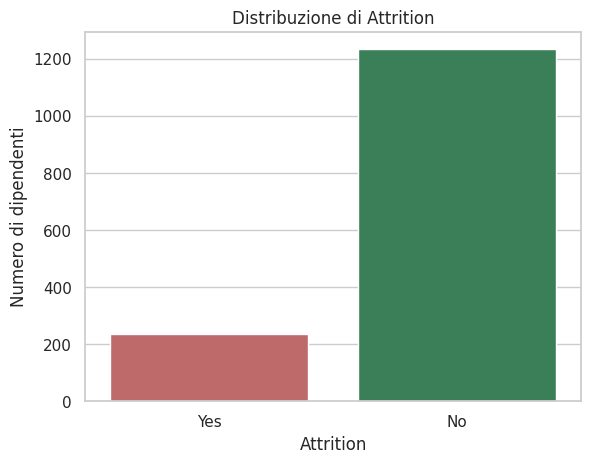

In [ ]:
# @title
sns.countplot(data=df_EA, x="Attrition", hue="Attrition", palette={"No": "seagreen", "Yes": "indianred"}, legend=False)
plt.title("Distribuzione di Attrition")
plt.xlabel("Attrition")
plt.ylabel("Numero di dipendenti")
plt.show()

La variabile target è fortemente sbilanciata: *1233 dipendenti*
(**83,9%**) sono rimasti in azienda e solo *237* (**16,1%**) hanno abbandonato. La variabile che ci interessa prevedere è quindi la minoranza del dataset.



Partendo dalle osservazioni emerse nella
Fase 1, formuliamo alcune ipotesi e le verifichiamo visivamente con *seaborn*,
con l'obiettivo di capire quali variabili sono più utili per prevedere l'abbandono
e quindi da tenere in considerazione nella successiva fase di modellazione.
Sono escluse le variabili costanti o identificative `Over18`, `EmployeeCount`, `StandardHours`, `EmployeeNumber`.

### 2.2 Quali variabili numeriche sono legate di più all'abbandono?

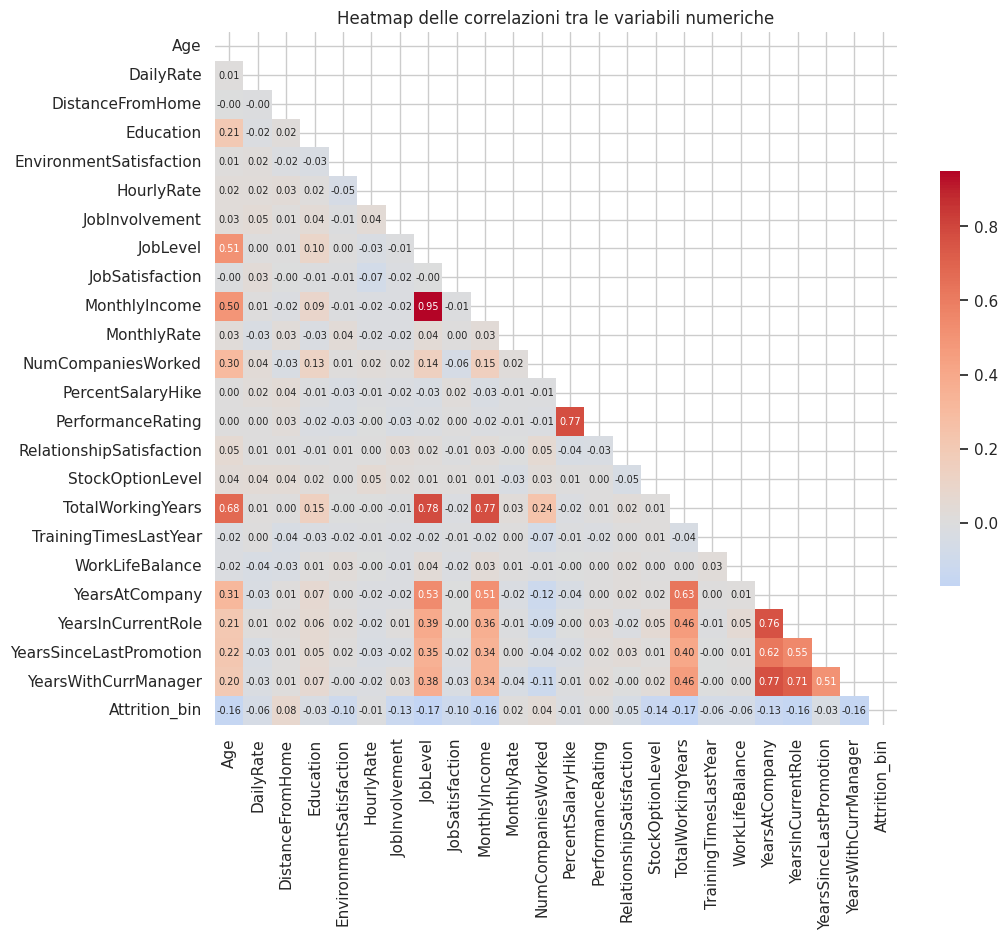

In [ ]:
# @title
var_esc= ["EmployeeCount", "StandardHours", "EmployeeNumber"]
num_cols = [c for c in df_EA.select_dtypes(include="number").columns if c not in var_esc]
corr = df_EA[num_cols].corr()

triang=np.triu(np.ones_like(corr,dtype=bool))

plt.figure(figsize=(11, 9))
sns.heatmap(corr, mask=triang, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.6})
plt.title("Heatmap delle correlazioni tra le variabili numeriche")
plt.show()

Guardando la riga di `Attrition_bin`, le variabili più legate all'abbandono hanno tutte una
**relazione negativa**: `TotalWorkingYears`, `JobLevel`, `MonthlyIncome`, `Age` e le variabili
sugli anni di anzianità si muovono intorno a −0,16/−0,17. Il segno negativo significa in questo caso che più
queste variabili crescono (più esperienza, livello, reddito, età, anzianità), più l'abbandono
diminuisce: sono quindi fattori che tendono a trattenere i dipendenti. Tra le numeriche non ci
sono relazioni positive forti con l'abbandono; l'unica leggermente **positiva** è
`DistanceFromHome` (+0,08), cioè chi abita più lontano abbandona un po' di più, ma il legame è
molto debole. Diverse variabili hanno invece una **relazione neutra**, con valore vicino a zero
(`MonthlyRate`, `HourlyRate`, `PercentSalaryHike`, `PerformanceRating`, `Education`): con
l'abbandono non hanno praticamente alcun legame. Va ricordato che, trattandosi della correlazione
con la variabile target, questi valori sono naturalmente bassi e vanno letti in senso relativo
(ovvero quali variabili sono le più correlate rispetto alle altre), non come correlazioni forti in assoluto.

Dallo stesso grafico è possibile desumere le correlazioni **tra le stesse variabili**, che qui sono tutte
**positive** e in alcuni casi molto forti in assoluto. `JobLevel` e `MonthlyIncome` hanno una
correlazione di 0,95: crescono quasi insieme, ipotizziamo dunque da questo risultato che a un livello più alto corrisponde uno
stipendio più alto. Allo stesso modo le variabili sugli anni (`YearsAtCompany`,
`YearsInCurrentRole`, `YearsWithCurrManager`) sono correlate positivamente tra loro intorno a
0,7, e `Age` con `TotalWorkingYears` a 0,68. Queste forti relazioni positive indicano che le
variabili dentro ciascun gruppo portano quasi la stessa informazione.

Dalla lettura di questa *heatmap* ricaviamo il criterio che ci guiderà durante l'analisi visiva, infatti, andremo ad approfondire solo le
variabili con una relazione (negativa o positiva) apprezzabile con l'abbandono, e tra quelle molto
correlate tra loro per poter fare anche dei confronti tra gruppi/categorie.

### Heatmap variabili caregoriche

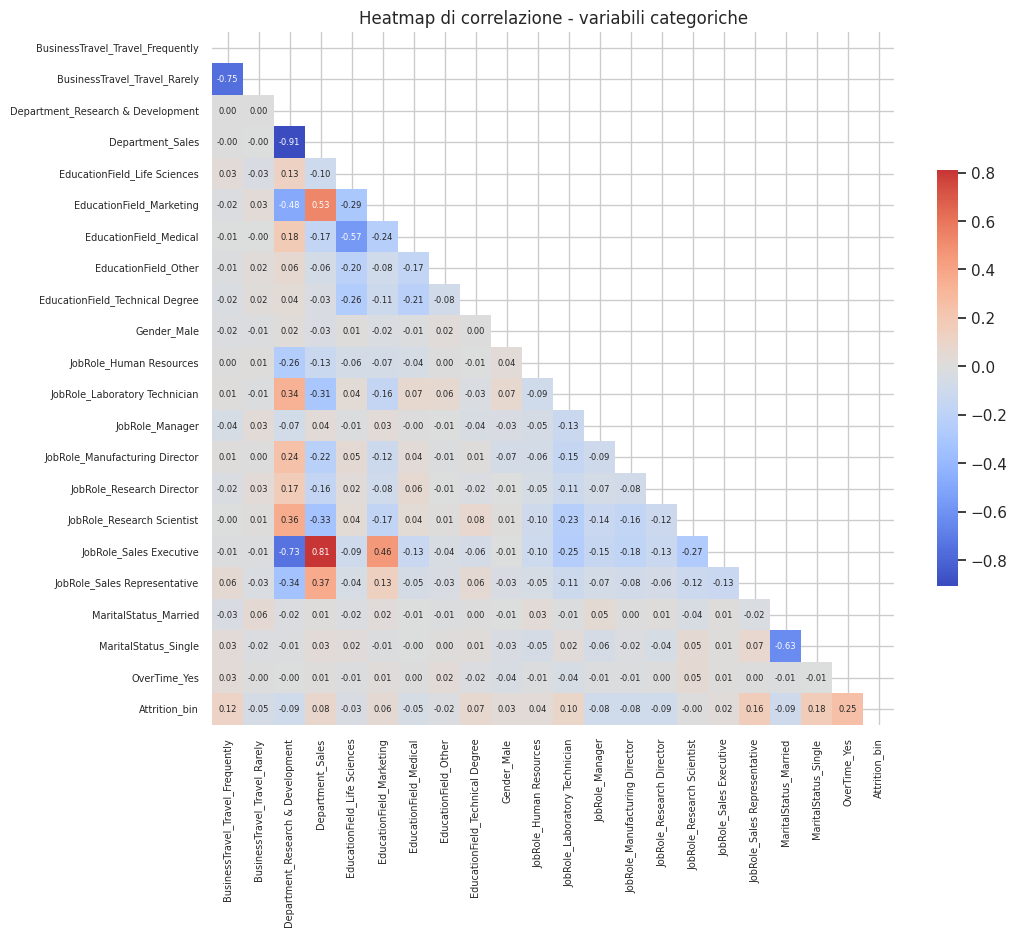

In [ ]:
# @title
#per la creazione del grafico trasformiamo le categoriche in 0/1
categoriche = ["BusinessTravel", "Department", "EducationField",
               "Gender", "JobRole", "MaritalStatus", "OverTime"]
data = pd.get_dummies(df_EA[categoriche], drop_first=True)
data["Attrition_bin"] = df_EA["Attrition_bin"]

corr = data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 6}, cbar_kws={"shrink": 0.6})
plt.title("Heatmap di correlazione - variabili categoriche")
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)
plt.show()

Anche qui leggiamo la heatmap su due livelli come abbiamo fatto precedentemente, ricordando che le variabili
categoriche sono state trasformate in 0/1.

Partendo dalla riga di `Attrition_bin`, le categorie con una **relazione positiva** con
l'abbandono (cioè che lo favoriscono) sono `OverTime_Yes` (+0,25), `MaritalStatus_Single`
(+0,18), `JobRole_Sales Representative` (+0,16) e `BusinessTravel_Travel_Frequently` (+0,12):
chi fa straordinari, chi è single, chi è Sales Representative e chi viaggia spesso tende ad
abbandonare di più. Sul lato opposto troviamo categorie con **relazione negativa**, che quindi
trattengono i lavoratori: `Department_Research & Development` e `MaritalStatus_Married` (circa −0,09),
`JobRole_Research Director`, `JobRole_Manager` e `JobRole_Manufacturing Director` (intorno a
−0,08). Diverse categorie sono invece **neutre**, con valore vicino a zero, come
`JobRole_Sales Executive`, `Gender_Male` o alcuni ambiti di studio: queste non incidono sull'abbandono.
Come per le numeriche, i valori sono naturalmente bassi e vanno letti in senso relativo:
`OverTime` resta comunque la variabile più correlata in assoluto con l'abbandono in tutto il dataset.

Il secondo livello che andiamo a guardare è sempre quello delle correlazioni **tra le variabili**. Qui si vedono alcune caselle
blu molto intense, cioè **relazioni negative forti**, che però sono un effetto della codifica e
non vanno interpretate: per esempio `Department_Research & Development` e `Department_Sales` sono
fortemente negative tra loro (circa −0,8), così come `BusinessTravel_Travel_Rarely` e
`Travel_Frequently` (−0,75) o `MaritalStatus_Single` e `Married` (−0,61). Questi valori sono normali perché le
categorie di una stessa variabile si escludono a vicenda: ad esempio, un dipendente che è in un reparto non
può essere nell'altro. Si notano invece alcune **relazioni positive** sensate tra variabili
diverse, ad esempio tra i ruoli di Sales e il reparto Sales, perché quei ruoli appartengono a
quel dipartimento.

In sintesi, tra le categoriche le più utili per prevedere l'abbandono sono `OverTime`,
`MaritalStatus` (single) e `JobRole` (in particolare Sales Representative), *mentre le correlazioni
forti tra le colonne vanno lette con attenzione perché spesso derivano semplicemente dalla codifica*.

### 2.3 L'età incide sull'abbandono?

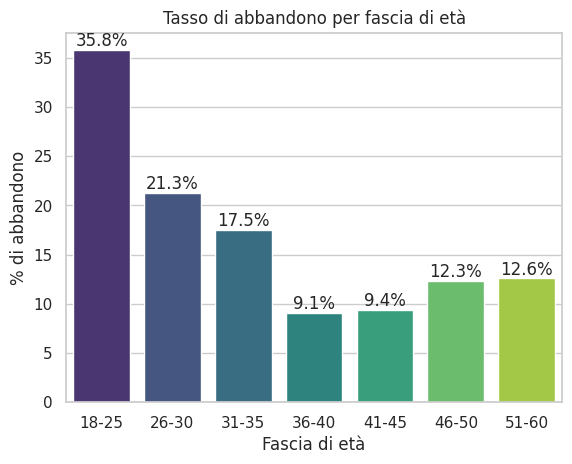

In [ ]:
# @title
fasce_eta= pd.cut(df_EA["Age"], bins=[17, 25, 30, 35, 40, 45, 50, 60])
percentuale= df_EA.groupby(fasce_eta, observed=True)["Attrition_bin"].mean() * 100

etichette = ["18-25", "26-30", "31-35", "36-40", "41-45", "46-50", "51-60"]
ax = sns.barplot(x=etichette, y=percentuale.values, hue=etichette, palette="viridis", legend=False)
for i, v in enumerate(percentuale.values):
    ax.text(i, v, f"{v:.1f}%", ha="center", va="bottom")

plt.title("Tasso di abbandono per fascia di età")
plt.xlabel("Fascia di età")
plt.ylabel("% di abbandono")
plt.show()

Il grafico mostra il tasso di abbandono diviso per fasce di età, ed emerge
un andamento molto chiaro. I dipendenti più giovani abbandonano nettamente di più: nella fascia
18-25 anni se ne va il **35,8%**, più del doppio della media del dataset. Il tasso poi scende in modo
costante con l'età, fino a toccare il minimo (circa **9%**) nelle fasce 36-40 e 41-45 anni.

Dopo i 45 anni si nota una leggera risalita (**12,3%** e **12,6%**), ma resta comunque molto lontana dai
valori dei lavoratori più giovani. Nel complesso, quindi, l'età ha una relazione negativa con l'abbandono:
più aumenta, più la propensione ad andarsene diminuisce. Questo conferma quanto visto nella
heatmap, ovvero `Age` tra le variabili più correlate con segno negativo.
Dalla visione del grafico ipotizziamo che i giovani a inizio carriera sono meno radicati e più disposti a cambiare lavoro.

### 2.4 Uomini e donne abbandonano in proporzioni diverse?

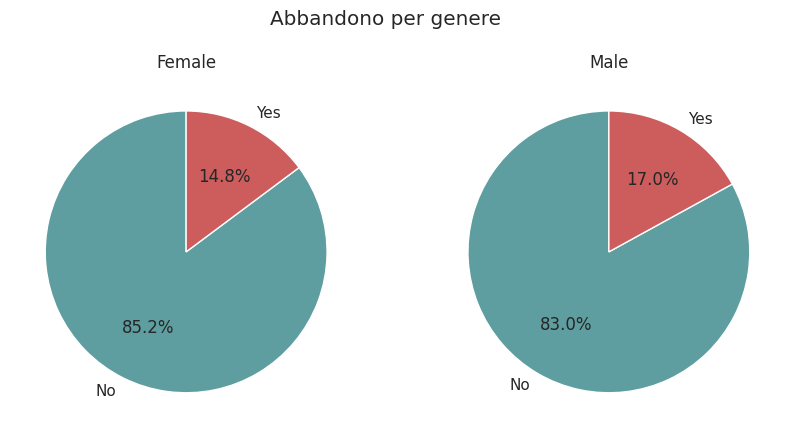

In [ ]:
# @title
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, genere in zip(axes, ["Female", "Male"]):
    conteggi = df_EA[df_EA["Gender"] == genere]["Attrition"].value_counts()
    ax.pie(conteggi, labels=conteggi.index, autopct="%1.1f%%",
           colors=[pal[k] for k in conteggi.index], startangle=90)
    ax.set_title(genere)

plt.suptitle("Abbandono per genere")
plt.show()

Le due torte mostrano, separatamente per donne e uomini, la quota di chi
resta e di chi abbandona. In entrambi i casi la grande maggioranza dei dipendenti resta: la
fetta blu ("No") occupa la parte più grande sia per le donne (**85,2%**) sia per gli uomini (**83,0%**).

Confrontando le fette rosse ("Yes"), che rappresentano gli abbandoni, vediamo che gli uomini
abbandonano il **17,0%** e le donne il **14,8%**: gli uomini se ne vanno un po' di più, ma la differenza
è piccola, appena un paio di punti percentuali. Le due torte si somigliano molto, segno che il
genere non incide in modo rilevante sull'abbandono. Questo è coerente con quanto avevamo visto
nella heatmap, dove `Gender` aveva una correlazione quasi nulla con l'abbandono: per la Fase 4,
quindi, è una variabile poco utile a prevedere chi lascerà l'azienda.

### 2.5 Chi fa gli straordinari abbandona di più?

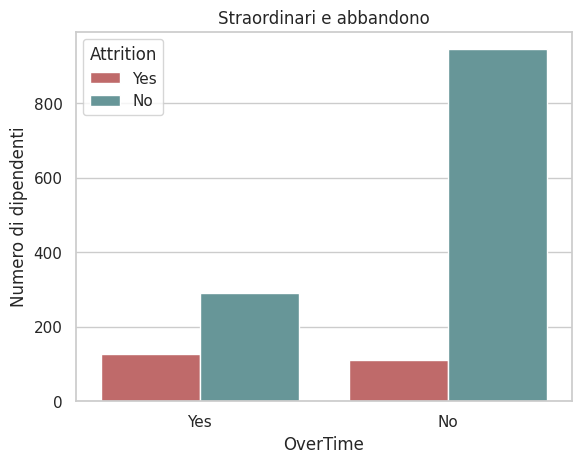

In [ ]:
# @title
sns.countplot(data=df_EA, x="OverTime", hue="Attrition", palette=pal)
plt.title("Straordinari e abbandono")
plt.xlabel("OverTime")
plt.ylabel("Numero di dipendenti")
plt.show()

Nel grafico vediamo che tra chi non fa straordinari la grande maggioranza resta: la barra blu è molto più alta di quella rossa. Tra chi fa straordinari, invece, il gruppo è più piccolo ma la barra degli abbandoni (rossa) diventa molto più consistente rispetto al totale di quel gruppo. Quindi chi fa `OverTime` abbandona in proporzione molto di più.

### 2.6 Chi guadagna meno abbandona di più?

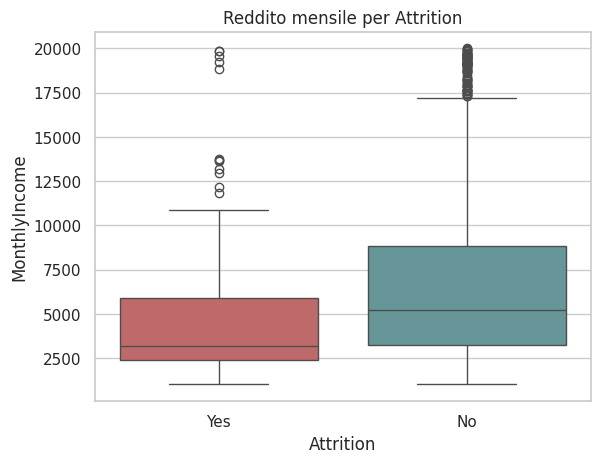

In [ ]:
# @title
sns.boxplot(data=df_EA, x="Attrition", y="MonthlyIncome", hue="Attrition", palette=pal, legend=False)
plt.title("Reddito mensile per Attrition")
plt.xlabel("Attrition")
plt.ylabel("MonthlyIncome")
plt.show()

Il boxplot mostra che chi abbandona ha una mediana del reddito chiaramente più bassa rispetto a chi resta, e che tutta la sua scatola è spostata verso il basso. In media, quindi, chi se ne va guadagna meno. Si notano anche parecchi valori in alto, cioè stipendi molto elevati, soprattutto tra chi resta. Il grafico conferma il legame negativo tra reddito e abbandono visto nella heatmap.

### 2.7 Chi è in azienda da meno tempo abbandona di più?

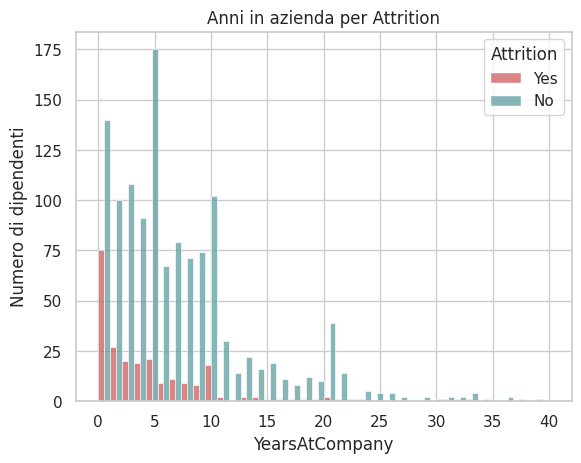

In [ ]:
# @title
sns.histplot(data=df_EA, x="YearsAtCompany", hue="Attrition", multiple="dodge", palette=pal)
plt.title("Anni in azienda per Attrition")
plt.xlabel("YearsAtCompany")
plt.ylabel("Numero di dipendenti")
plt.show()

L'istogramma mostra che gli abbandoni (ovvero le barre in rosso) sono concentrati soprattutto nei primi anni di anzianità, mentre man mano che gli anni aumentano diventano sempre più rari, quindi chi resta a lungo tende a rimanere. Questo ci fa ipotizzare l'idea che chi ha meno radici nell'azienda sia più propenso ad andarsene.

### 2.8 MaritalStatus è associato all'abbandono?

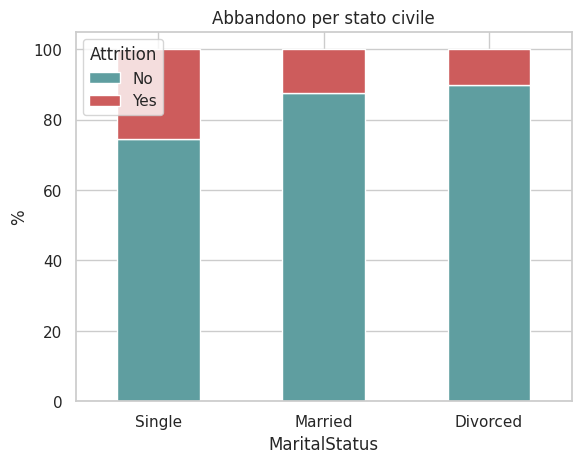

In [ ]:
# @title
tab = (pd.crosstab(df_EA["MaritalStatus"], df_EA["Attrition"], normalize="index")*100).reindex(["Single","Married","Divorced"])
tab.plot(kind="bar", stacked=True, color=["cadetblue", "indianred"])
plt.title("Abbandono per stato civile")
plt.xlabel("MaritalStatus")
plt.ylabel("%")
plt.legend(title="Attrition")
plt.xticks(rotation=0)
plt.show()

In questo grafico vediamo che il segmento rosso degli abbandoni è nettamente più grande per i single rispetto ai coniugati e ai divorziati. La proporzione di chi se ne va tra i single è quindi molto più alta. Questo conferma la relazione positiva tra essere single e abbandono vista nella heatmap delle variabili categoriche: una spiegazione potrebbe essere che chi è single abbia meno vincoli e più libertà di cambiare lavoro.

### 2.9 Il coinvolgimento riduce l'abbandono?

Nella fase precedente è emerso che `JobSatisfaction` incide sull'abbandono: anche chi è soddisfatto se ne va in percentuali non trascurabili. Questo ci fa pensare che la soddisfazione da sola non basti a spiegare perché un dipendente decide di andarsene.

Proviamo allora a guardare alla variabile `JobInvolvement`, che ci dice quanto il dipendente è coinvolto dal proprio lavoro, ipotizzando che chi è maggiormente coinvolto, sarà meno propenso ad abbandonare il posto di lavoro.

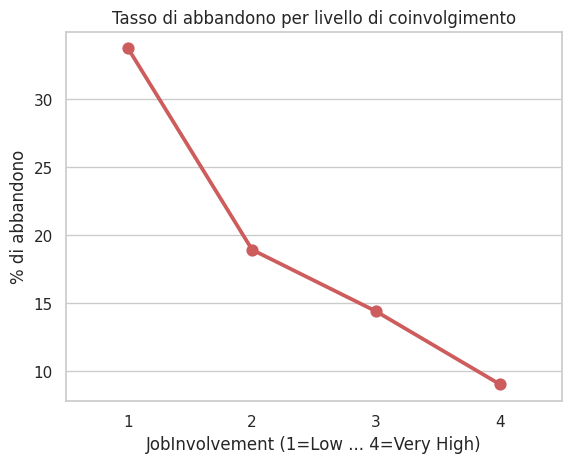

In [ ]:
# @title
perc_JI= calcola_percentuale("JobInvolvement")
sns.pointplot(x=perc_JI.index, y=perc_JI.values, color="indianred")
plt.title("Tasso di abbandono per livello di coinvolgimento")
plt.xlabel("JobInvolvement (1=Low ... 4=Very High)")
plt.ylabel("% di abbandono")
plt.show()

L'ipotesi è confermata: la frequenza di abbandono
diminuisce al crescere del coinvolgimento in modo costante, passando da circa **34%**
(*Low*) a circa **9%**(*Very High*). Dunque, chi è poco coinvolto abbandona quasi quattro volte di più rispetto a chi è molto coinvolto.

Il calo è costante a ogni livello, segno di una relazione chiara e non casuale tra
*coinvolgimento* e *abbandono*. Rispetto alla variabile  `JobSatisfaction` analizzata nella Fase 1
(che andava dal 22,8% all'11,3%), la variabile `JobInvolvement` mostra una differenza ancora
più marcata tra i gruppi.

### 2.10 Quale ruolo ha il tasso di abbandono più alto?

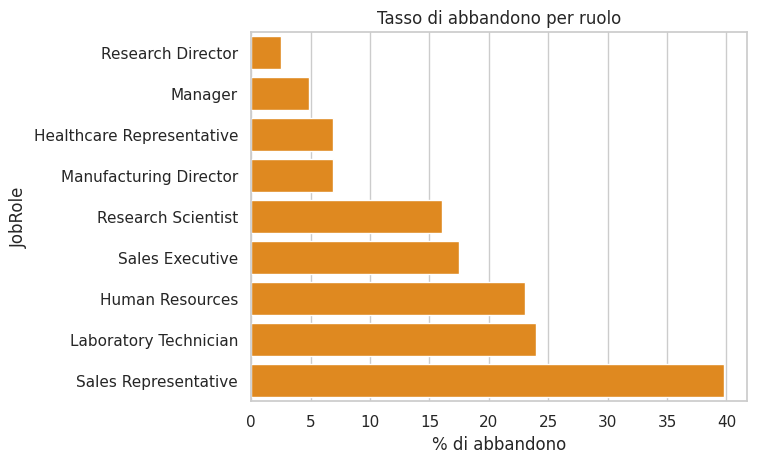

In [ ]:
# @title
perc = calcola_percentuale("JobRole").sort_values()
sns.barplot(x=perc.values, y=perc.index, color="darkorange")
plt.title("Tasso di abbandono per ruolo")
plt.xlabel("% di abbandono")
plt.ylabel("JobRole")
plt.show()

Le differenze tra ruoli sono molto forti: i *Sales Representative* abbandonano il **39,8%**, seguiti da *Laboratory Technician* (**23,9%**) e *Human Resources* (**23,1%**), mentre *Research Director* (**2,5%**), *Manager* (**4,9%**) e *Manufacturing Director* (**6,9%**) quasi non lasciano.

### 2.11 Il *MonthlyRate* distingue chi resta da chi abbandona?

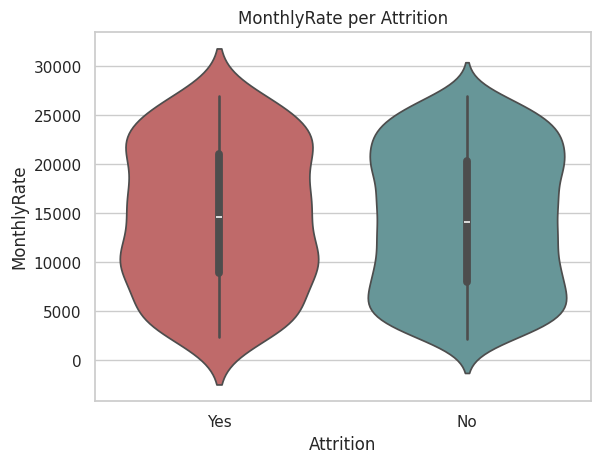

In [ ]:
# @title
sns.violinplot(data=df_EA, x="Attrition", y="MonthlyRate", hue="Attrition", palette=pal, legend=False)
plt.title("MonthlyRate per Attrition")
plt.xlabel("Attrition")
plt.ylabel("MonthlyRate")
plt.show()

No: le due distribuzioni sono praticamente identiche (media 14.559 contro il 14.266). Il `MonthlyRate` non sembra essere utile a prevedere l'abbandono.
Il grafico mostra visivamente che il `MonthlyRate` non distingue i due gruppi, ed è proprio per questo che lo abbiamo escluso dall'analisi. Questo conferma quanto avevamo letto nella heatmap delle variabili numeriche, dove `MonthlyRate` aveva una relazione neutra (vicina a zero) con l'abbandono.

### 2.12 Le *stock option* riducono il livello di abbandono?

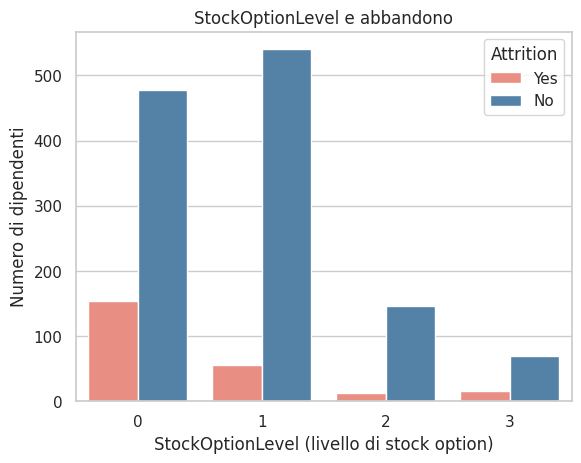

In [ ]:
# @title
sns.countplot(data=df_EA, x="StockOptionLevel", hue="Attrition",
              palette={"No": "steelblue",   "Yes": "salmon"})
plt.title("StockOptionLevel e abbandono")
plt.xlabel("StockOptionLevel (livello di stock option)")
plt.ylabel("Numero di dipendenti")
plt.show()

Chi non ha stock
option (*livello 0*) abbandona molto di più. Guardando il grafico infatti si nota subito che al livello 0 la barra
degli abbandoni è molto più alta rispetto agli altri livelli. Questo ci riporta all'idea che gli incentivi economici
trattengano i dipendenti, e che quindi avere delle stock option sia associato a un minor abbandono.
Dobbiamo tenere in considerazione però che i gruppi non hanno la stessa dimensione, soprattutto è importante notare la differenza del numero di dipendenti dal livello 0 al livello 3.

### 2.13 All'aumentare del livello, aumenta lo stipendio?

<Axes: xlabel='JobLevel', ylabel='MonthlyIncome'>

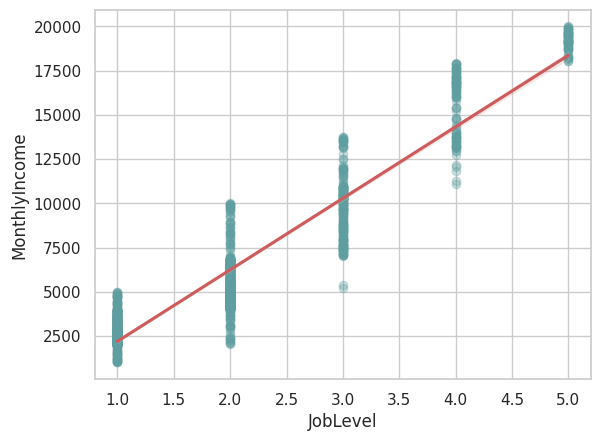

In [ ]:
# @title
sns.regplot(data=df_EA, x="JobLevel", y="MonthlyIncome",
              scatter_kws={"alpha": 0.3, "color": "cadetblue"}, line_kws={"color": "indianred"})

Lo scatterplot conferma in modo evidente quanto mostrava la heatmap: salendo
di livello di carriera, il reddito cresce in modo molto regolare. I punti si dispongono in fasce
nette e crescenti: al livello 1 gli stipendi sono bassi, al livello 5 sono tutti molto alti, si nota che quasi non c'è sovrapposizione tra un livello e l'altro. Le due variabili si muovono praticamente insieme: conoscere il livello di carriera equivale quasi a conoscere il reddito. Per la
Fase 4 usarle entrambe darebbe al modello la stessa informazione due volte, quindi
ne basta una.

### 2.14 L'età e gli anni di esperienza totale crescono insieme?

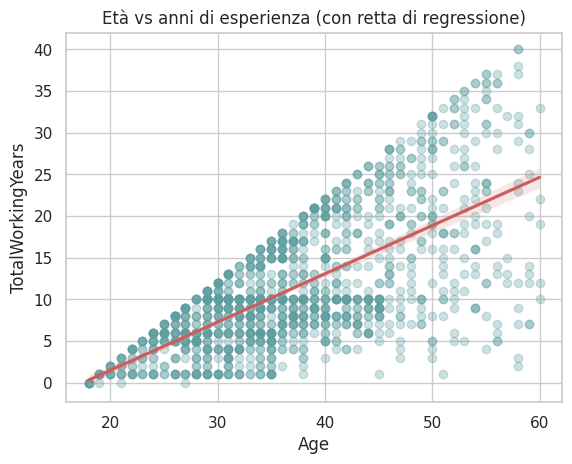

In [ ]:
# @title
sns.regplot(data=df_EA, x="Age", y="TotalWorkingYears",
            scatter_kws={"alpha": 0.3, "color": "cadetblue"}, line_kws={"color": "indianred"})
plt.title("Età vs anni di esperienza (con retta di regressione)")
plt.show()

Lo scatterplot con la retta di regressione mostra chiaramente la relazione tra
età ed esperienza lavorativa. La retta rossa è inclinata verso l'alto che ci fa capire che si tratta di una
correlazione **positiva**, cioè all'aumentare dell'età aumentano anche gli anni di esperienza totale.

Guardando l'andamento dei punti, si nota che la maggior parte segue l'andamento della retta, ma con una
certa dispersione, soprattutto per le età più alte: a parità di età ci sono persone con esperienze
diverse, per questo possiamo pensare al fatto che qualcuno ha iniziato a lavorare prima e qualcuno dopo, o ha avuto interruzioni. Si vede
anche un bordo netto nella parte bassa a sinistra, dovuto al fatto che non si può avere più anni di
lavoro che di età.

Età ed esperienza portano un'informazione molto simile, come avevamo già intuito dalla
heatmap. Questo conferma quanto già detto per la precedente correlazione: per la fase di
modellazione, è sufficiente tenerne una sola per non dare al modello la stessa informazione due volte.

### 2.15 Che relazione c'è tra il numero di aziende in cui un dipendente ha lavorato in passato e gli anni di permanenza nell'azienda attuale?

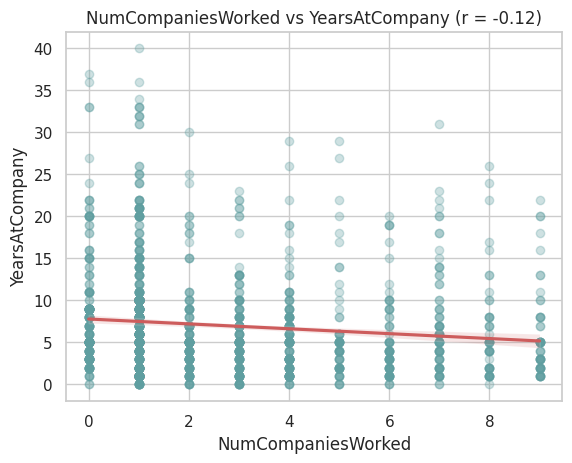

In [ ]:
# @title
r = df_EA["NumCompaniesWorked"].corr(df_EA["YearsAtCompany"])

sns.regplot(data=df_EA, x="NumCompaniesWorked", y="YearsAtCompany",
            scatter_kws={"alpha": 0.3, "color": "cadetblue"},
            line_kws={"color": "indianred"})
plt.title(f"NumCompaniesWorked vs YearsAtCompany (r = {r:.2f})")
plt.xlabel("NumCompaniesWorked")
plt.ylabel("YearsAtCompany")
plt.show()

A differenza dei confronti precedenti, qui la retta di regressione è inclinata
verso il **basso**: si tratta quindi di una correlazione **negativa**, cioè le due variabili tendono a
muoversi in versi opposti: più aumenta il numero di aziende in cui una persona ha
lavorato in passato, meno anni tende ad avere nell'azienda attuale: chi cambia spesso lavoro accumula
meno anzianità in un singolo posto.

Il legame, però, è **debole**: i punti sono dispersi nel grafico e la retta scende solo di
poco. In altre parole,questo grafico ci dice che conoscere il numero di aziende precedenti dice ben poco sugli anni di permanenza.
Questo è un caso diverso dalle coppie viste prima dove le variabili erano fortemente correlate, qui invece la relazione è negativa e quasi assente, segno che `NumCompaniesWorked` e
`YearsAtCompany` portano informazioni in gran parte **indipendenti**.

### Riflessione sui dati

Come già indicato nella Fase 1 abbiamo escluso le variabili prive di valore informativo: `Over18` (tutti i dipendenti sono maggiorenni), `EmployeeCount` (vale sempre 1) e `StandardHours` (vale sempre 80) sono costanti, mentre `EmployeeNumber` è soltanto un codice identificativo del dipendente. A queste si aggiunge `PerformanceRating`, che già nella fase precedente si era rivelata anomala: contiene solo i valori 3 e 4 (mancano i livelli 1 e 2), risultando una variabile incompleta.

L'analisi visiva e soprattutto la heatmap hanno permesso di capire quali tra le variabili rimanenti pesano davvero sull'abbandono. Il segnale più forte in assoluto è `OverTime`: chi fa straordinari abbandona il **30,5%** contro il **10,4%**, ed è la variabile più correlata con il target di tutto il dataset. Subito dopo troviamo lo stato civile `MaritalStatus`, con i single che abbandonano molto più dei coniugati, il ruolo `JobRole`, che varia enormemente da un **39,8%** dei Sales Representative a un **2,5%** dei Research Director, e la frequenza dei viaggi di lavoro `BusinessTravel`. Hanno un peso importante anche il coinvolgimento nel lavoro `JobInvolvement`, che fa scendere l'abbandono dal **34%** al **9%**, le stock option `StockOptionLevel` e il reddito mensile `MonthlyIncome`, insieme alle variabili legate a età, esperienza, livello di carriera e anzianità (`Age`, `TotalWorkingYears`, `JobLevel`, `YearsAtCompany`), tutte con una relazione negativa: più aumentano, più l'abbandono diminuisce.
Infine, anche la soddisfazione lavorativa e quella per l'ambiente (`JobSatisfaction`, `EnvironmentSatisfaction`) mostrano un effetto, anche se più contenuto.

Un aspetto importante emerso dalla heatmap è che diverse di queste variabili utili sono però molto correlate tra loro, quindi portano in gran parte la stessa informazione. In particolare `JobLevel` e `MonthlyIncome` hanno una correlazione di **0,95**, `Age` e `TotalWorkingYears` di **0,68**, e le variabili sugli anni di anzianità (`YearsAtCompany`, `YearsInCurrentRole`, `YearsWithCurrManager`) si muovono insieme intorno a **0,7**. Per la modellazione questo significa che non conviene usarle tutte insieme, ma sarebbe meglio scegliere una variabile per ciascuno di questi gruppi, per non dare al modello la stessa informazione ripetuta.

Ci sono poi diverse variabili cherisultano poco o per nulla legate all'abbandono. `MonthlyRate`, `HourlyRate` e `DailyRate`, insieme a `PercentSalaryHike`, hanno una correlazione praticamente nulla con il target. Anche `RelationshipSatisfaction`, `WorkLifeBalance`, `TrainingTimesLastYear`, `NumCompaniesWorked`, `YearsSinceLastPromotion` e `DistanceFromHome` portano un segnale debole.

# Fase 3 - Modellazione

Requisiti - almeno:

* 3 modelli diversi
    *   uno lineare (e.g. regressione)
    *   uno non lineare (e.g. k-nn e random forest)


Requisiti - per ogni modello:
* accuracy;
* confusion matrix;
* precision;
* recall;
* f1-score

##Preparazione dell'ambiente

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
    )


##Pulizia dataset
Come analizzato nelle fasi precenti, alcune variabili presentano delle caratteristiche non adatte all'analisi dei dati.
Saranno pertanto rimosse, in quanto porterebbero solo rumore ai modelli, le seguenti variabili:
* `Over18`, poichè tutti i dipendenti sono maggiorenni
* `EmployeeCount`, poichè vale sempre 1
* `StandardHours`, poichè vale sempre 8
* `EmployeeNumber`, dato che è soltanto un codice identificativo del dipendente
* `PerformanceRating`, che contiene solo i valori 3 e 4 (mancano i livelli 1 e 2), risultando una variabile incompleta

In [18]:
df_EA_clean=df_EA.drop(columns=["EmployeeCount", "EmployeeNumber", "Over18", "StandardHours", "PerformanceRating"])
df_EA_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

Convertiamo le variabili categoriche in variabili numeriche

In [23]:
#Iniziamo con le variabili categoriche binarie

df_EA_clean["Attrition"]=df_EA_clean["Attrition"].map({"No": 0, "Yes": 1})
df_EA_clean["Gender"]=df_EA_clean["Gender"].map({"Female": 0, "Male": 1})
df_EA_clean["OverTime"]=df_EA_clean["OverTime"].map({"No": 0, "Yes": 1})

In [20]:
#Passiamo alle variabili categoriche nominali
df_EA_clean=pd.get_dummies(df, columns=["Department", "EducationField", "JobRole", "MaritalStatus"], drop_first=True)

In [21]:
#Infine le variabili categoriche ordinali
mappa_viaggi={"Travel_Rarely": 0, "Travel_Frequently": 1, "Non-Travel": 2}
df_EA_clean["BusinessTravel"]=df_EA_clean["BusinessTravel"].map(mappa_viaggi)

In [24]:
df_EA_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 48 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Age                                1470 non-null   int64 
 1   Attrition                          1470 non-null   int64 
 2   BusinessTravel                     1470 non-null   int64 
 3   DailyRate                          1470 non-null   int64 
 4   DistanceFromHome                   1470 non-null   int64 
 5   Education                          1470 non-null   int64 
 6   EmployeeCount                      1470 non-null   int64 
 7   EmployeeNumber                     1470 non-null   int64 
 8   EnvironmentSatisfaction            1470 non-null   int64 
 9   Gender                             1470 non-null   int64 
 10  HourlyRate                         1470 non-null   int64 
 11  JobInvolvement                     1470 non-null   int64 
 12  JobLev